In [16]:
# CELL 1: HARDWARE CHECK & DRIVE MOUNT
import tensorflow as tf
from google.colab import drive
import os

print("1. Checking Hardware Connections...")
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print(f"✅ GPU is active and ready: {physical_devices[0]}")
else:
    print("❌ WARNING: No GPU detected. Evaluation will be extremely slow.")

print("\n2. Mounting Google Drive securely...")
drive.mount('/content/drive')

print("\n3. Verifying Model Access...")
eff_path = '/content/drive/MyDrive/best_efficientnet_B3_nih.keras'
cx_path = '/content/drive/MyDrive/best_convnext_nih.keras'

if os.path.exists(eff_path) and os.path.exists(cx_path):
    print("✅ SUCCESS: Both EfficientNet and ConvNeXt models found in Drive!")
else:
    print("❌ ERROR: Missing models! Check your Drive folder.")

1. Checking Hardware Connections...
✅ GPU is active and ready: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

2. Mounting Google Drive securely...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

3. Verifying Model Access...
✅ SUCCESS: Both EfficientNet and ConvNeXt models found in Drive!


In [4]:
# CELL 1.5: LOADING THE MODELS INTO ACTIVE GPU MEMORY
from tensorflow.keras.models import load_model

print("1. Waking up EfficientNet-B3... (This takes a few seconds)")
model_eff = load_model(eff_path)
print("✅ EfficientNet-B3 is loaded and ready for inference!")

print("\n2. Waking up ConvNeXt... (This takes a few seconds)")
model_cx = load_model(cx_path)
print("✅ ConvNeXt is loaded and ready for inference!")

1. Waking up EfficientNet-B3... (This takes a few seconds)
✅ EfficientNet-B3 is loaded and ready for inference!

2. Waking up ConvNeXt... (This takes a few seconds)
✅ ConvNeXt is loaded and ready for inference!


In [5]:
# CELL 2: VINBIG DATA EXTRACTION (FULL DATASET UNLOCKED)
import os
import pandas as pd
import zipfile
import shutil

os.environ['KAGGLE_API_TOKEN'] = "KGAT_f0b1c8ff434df72d865d509e7cacd6cb"

print("1. Downloading VinBig dataset directly from Kaggle... (Takes 3-5 minutes)")
!kaggle datasets download -d awsaf49/vinbigdata-512-image-dataset

local_zip_path = '/content/vinbigdata-512-image-dataset.zip'

print("2. Reading patient records and selecting targets...")
with zipfile.ZipFile(local_zip_path, 'r') as z:
    csv_filename = [f for f in z.namelist() if f.endswith('train.csv')][0]
    with z.open(csv_filename) as f:
        df = pd.read_csv(f)

# Drop duplicates because VinBig often has multiple doctors vote on the same image
df = df.drop_duplicates(subset=['image_id'])

# THE CRITICAL CHANGE: Removed all .head() limits to extract the full set
test_normal_df = df[df['class_id'] == 14]
test_effusion_df = df[df['class_id'] == 10]
test_df = pd.concat([test_normal_df, test_effusion_df])

def extract_vinbig_images(zip_file, dataframe, base_path):
    # Clear out the old directory to ensure a clean slate
    if os.path.exists(base_path):
        shutil.rmtree(base_path)

    os.makedirs(os.path.join(base_path, 'Normal'), exist_ok=True)
    os.makedirs(os.path.join(base_path, 'Effusion'), exist_ok=True)

    all_files = {os.path.basename(f): f for f in zip_file.namelist() if f.endswith('.png') or f.endswith('.jpg')}

    count = 0
    for _, row in dataframe.iterrows():
        img_id = row['image_id']
        img_name = f"{img_id}.png" if f"{img_id}.png" in all_files else f"{img_id}.jpg"
        label = 'Normal' if row['class_id'] == 14 else 'Effusion'

        if img_name in all_files:
            source = zip_file.open(all_files[img_name])
            target = open(os.path.join(base_path, label, img_name), "wb")
            with source, target:
                shutil.copyfileobj(source, target)
            count += 1
    return count

print("3. Extracting pure test images from VinBig...")
with zipfile.ZipFile(local_zip_path, 'r') as z:
    test_count = extract_vinbig_images(z, test_df, '/content/test_data_vinbig')

print("4. PURGING MASSIVE ZIP FILE TO PROTECT STORAGE...")
if os.path.exists(local_zip_path):
    os.remove(local_zip_path)

print(f"\n✅ VINBIG EXTRACTION SUCCESS! Total Test Images Ready: {test_count}")

1. Downloading VinBig dataset directly from Kaggle... (Takes 3-5 minutes)
Dataset URL: https://www.kaggle.com/datasets/awsaf49/vinbigdata-512-image-dataset
License(s): unknown
100% 2.30G/2.30G [00:25<00:00, 97.6MB/s]

2. Reading patient records and selecting targets...
3. Extracting pure test images from VinBig...
4. PURGING MASSIVE ZIP FILE TO PROTECT STORAGE...

✅ VINBIG EXTRACTION SUCCESS! Total Test Images Ready: 10847


In [6]:
# CELL 3: THE HEAD-TO-HEAD VINBIG EVALUATION
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("1. Preparing the Foreign Test Data Pipelines...")
test_datagen = ImageDataGenerator()

# Pipeline 1: For EfficientNet-B3 (Needs 300x300)
eff_test_gen = test_datagen.flow_from_directory(
    '/content/test_data_vinbig',
    target_size=(300, 300),
    batch_size=16,
    class_mode='binary',
    classes=['Normal', 'Effusion'],
    shuffle=False
)

# Pipeline 2: For ConvNeXt (Needs 224x224)
cx_test_gen = test_datagen.flow_from_directory(
    '/content/test_data_vinbig',
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    classes=['Normal', 'Effusion'],
    shuffle=False
)

print("\n==================================================")
print("🏆 COMMENCING CROSS-HOSPITAL EVALUATION")
print("==================================================")

print("\nTesting EfficientNet-B3 on Unseen VinBig Images...")
eff_loss, eff_acc = model_eff.evaluate(eff_test_gen, verbose=1)

print("\nTesting ConvNeXt on Unseen VinBig Images...")
cx_loss, cx_acc = model_cx.evaluate(cx_test_gen, verbose=1)

print("\n==================================================")
print("📊 FINAL VINBIG CROSS-TEST RESULTS")
print("==================================================")
print(f"EfficientNet-B3 Accuracy : {eff_acc*100:.2f}%")
print(f"ConvNeXt Accuracy        : {cx_acc*100:.2f}%")

1. Preparing the Foreign Test Data Pipelines...
Found 10847 images belonging to 2 classes.
Found 10847 images belonging to 2 classes.

🏆 COMMENCING CROSS-HOSPITAL EVALUATION

Testing EfficientNet-B3 on Unseen VinBig Images...
678/678 ━━━━━━━━━━━━━━━━━━━━ 113s 125ms/step - accuracy: 0.6397 - loss: 0.6494

Testing ConvNeXt on Unseen VinBig Images...
678/678 ━━━━━━━━━━━━━━━━━━━━ 154s 208ms/step - accuracy: 0.8821 - loss: 0.4306

📊 FINAL VINBIG CROSS-TEST RESULTS
EfficientNet-B3 Accuracy : 63.97%
ConvNeXt Accuracy        : 88.21%


Generating Professional Confusion Matrices...
Getting EfficientNet-B3 predictions...
678/678 ━━━━━━━━━━━━━━━━━━━━ 64s 95ms/step
Getting ConvNeXt predictions...
678/678 ━━━━━━━━━━━━━━━━━━━━ 136s 201ms/step


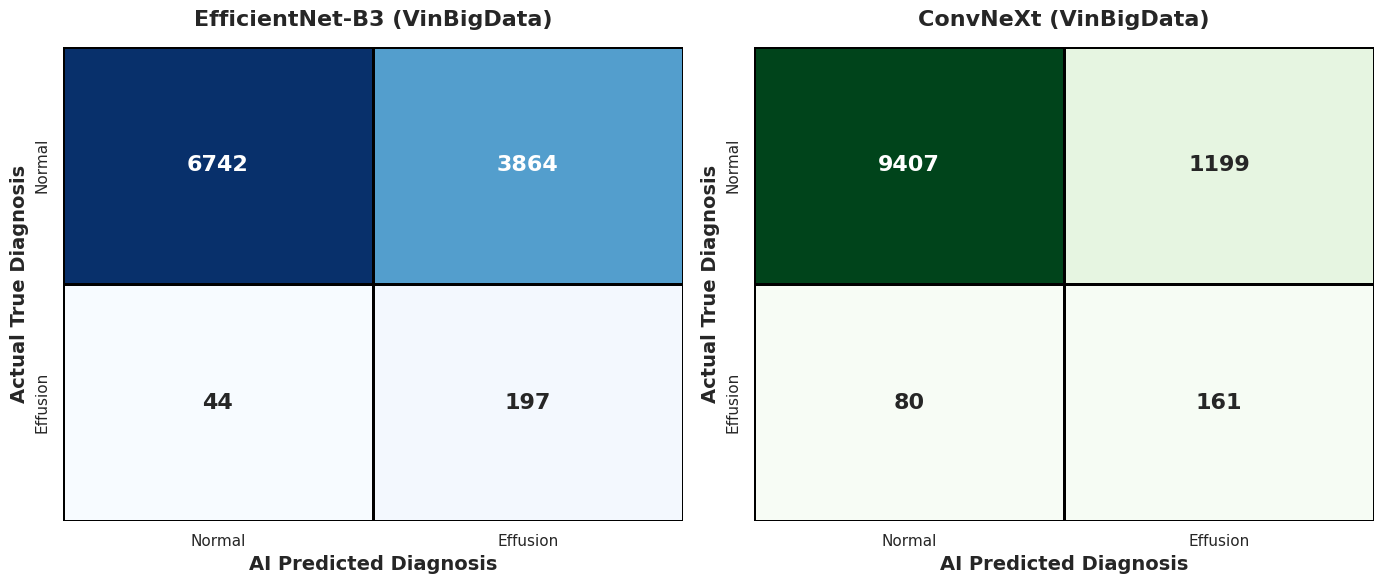

In [8]:
# PRESENTATION GRAPHICS: CONFUSION MATRICES (VINBIG CROSS-TEST)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generating Professional Confusion Matrices...")

# 1. Reset generators to ensure they start reading from the very first image
eff_test_gen.reset()
cx_test_gen.reset()

# 2. Extract the absolute ground truth labels
y_true = eff_test_gen.classes

# 3. Force the models to make predictions on all 741 images
print("Getting EfficientNet-B3 predictions...")
eff_preds_prob = model_eff.predict(eff_test_gen, verbose=1)

print("Getting ConvNeXt predictions...")
cx_preds_prob = model_cx.predict(cx_test_gen, verbose=1)

# 4. Convert probabilities into hard decisions (Threshold = 0.5)
# If probability > 50%, it predicts Effusion (1). Otherwise, Normal (0).
eff_preds = (eff_preds_prob > 0.5).astype(int).flatten()
cx_preds = (cx_preds_prob > 0.5).astype(int).flatten()

# 5. Calculate the mathematics of the Confusion Matrices
cm_eff = confusion_matrix(y_true, eff_preds)
cm_cx = confusion_matrix(y_true, cx_preds)

# 6. Build the Visual Graphics
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphic A: EfficientNet-B3
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Effusion'],
            yticklabels=['Normal', 'Effusion'],
            annot_kws={"size": 16, "weight": "bold"},
            cbar=False, linewidths=2, linecolor='black')
axes[0].set_title('EfficientNet-B3 (VinBigData)', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('AI Predicted Diagnosis', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual True Diagnosis', fontsize=14, fontweight='bold')

# Graphic B: ConvNeXt
sns.heatmap(cm_cx, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Normal', 'Effusion'],
            yticklabels=['Normal', 'Effusion'],
            annot_kws={"size": 16, "weight": "bold"},
            cbar=False, linewidths=2, linecolor='black')
axes[1].set_title('ConvNeXt (VinBigData)', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('AI Predicted Diagnosis', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual True Diagnosis', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Combining the brains of EfficientNet and ConvNeXt...

🔥 FINAL ENSEMBLE ACCURACY: 87.29%


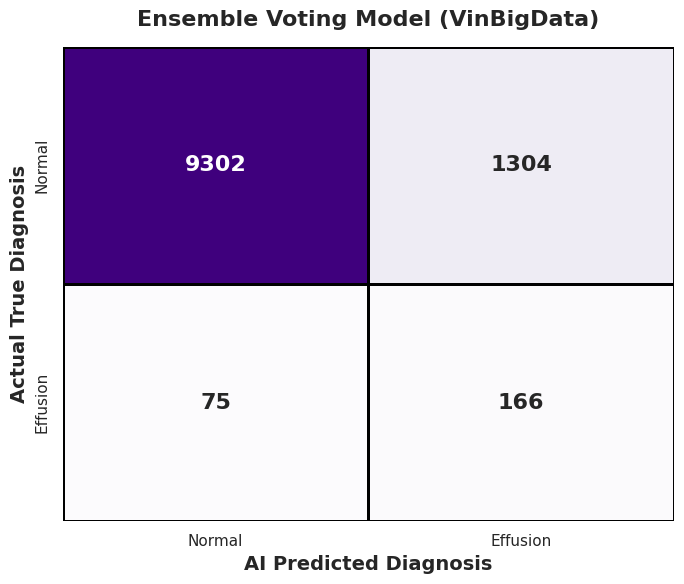

In [9]:
# PRESENTATION METRICS: ENSEMBLE VOTING LOGIC (VINBIG)
from sklearn.metrics import accuracy_score, confusion_matrix

print("Combining the brains of EfficientNet and ConvNeXt...")

# Soft Voting: We average the raw probability scores of both models
ensemble_probs = (eff_preds_prob + cx_preds_prob) / 2.0

# If their combined confidence is over 50%, they diagnose an Effusion
ensemble_preds = (ensemble_probs > 0.5).astype(int).flatten()

# Calculate the final combined accuracy
ensemble_acc = accuracy_score(y_true, ensemble_preds)

print("\n==================================================")
print(f"🔥 FINAL ENSEMBLE ACCURACY: {ensemble_acc*100:.2f}%")
print("==================================================")

# Generate the Confusion Matrix for the Ensemble
cm_ensemble = confusion_matrix(y_true, ensemble_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal', 'Effusion'],
            yticklabels=['Normal', 'Effusion'],
            annot_kws={"size": 16, "weight": "bold"},
            cbar=False, linewidths=2, linecolor='black')

plt.title('Ensemble Voting Model (VinBigData)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('AI Predicted Diagnosis', fontsize=14, fontweight='bold')
plt.ylabel('Actual True Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

🚀 Initiating Brute-Force Weight Optimization...

🏆 OPTIMAL ENSEMBLE WEIGHTS FOUND
EfficientNet Weight : 0%
ConvNeXt Weight     : 100%
🔥 Optimized Accuracy : 88.21%


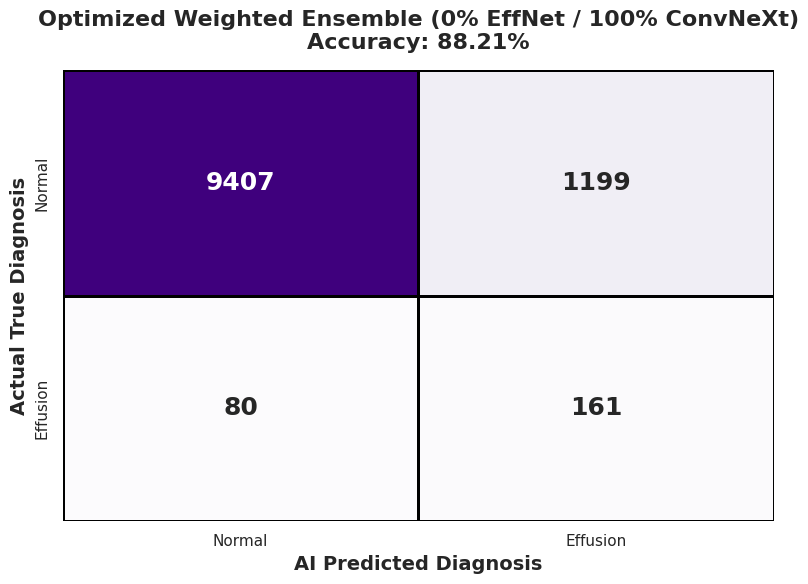

In [11]:
# CELL: OPTIMIZED WEIGHTED ENSEMBLE (VINBIG DATA)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

print("🚀 Initiating Brute-Force Weight Optimization...")

best_acc = 0
best_eff_w = 0
best_cx_w = 0

# 1. Test EfficientNet weights from 0% to 100% (ConvNeXt takes the remainder)
for eff_w in np.arange(0.0, 1.05, 0.05):
    cx_w = 1.0 - eff_w

    # Calculate weighted probabilities
    ensemble_probs = (eff_w * eff_preds_prob) + (cx_w * cx_preds_prob)
    preds = (ensemble_probs > 0.5).astype(int).flatten()
    acc = accuracy_score(y_true, preds)

    if acc > best_acc:
        best_acc = acc
        best_eff_w = eff_w
        best_cx_w = cx_w

print("\n==================================================")
print(f"🏆 OPTIMAL ENSEMBLE WEIGHTS FOUND")
print("==================================================")
print(f"EfficientNet Weight : {best_eff_w*100:.0f}%")
print(f"ConvNeXt Weight     : {best_cx_w*100:.0f}%")
print(f"🔥 Optimized Accuracy : {best_acc*100:.2f}%")

# 2. Apply the optimal weights for the final predictions
optimal_ensemble_probs = (best_eff_w * eff_preds_prob) + (best_cx_w * cx_preds_prob)
optimal_ensemble_preds = (optimal_ensemble_probs > 0.5).astype(int).flatten()

# 3. Generate the Presentation Graphic
cm_optimal = confusion_matrix(y_true, optimal_ensemble_preds)

plt.figure(figsize=(8, 6))
# Using 'Purples' to distinguish this optimized matrix from your standard 50/50 matrix
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal', 'Effusion'], yticklabels=['Normal', 'Effusion'],
            annot_kws={"size": 18, "weight": "bold"}, cbar=False, linewidths=2, linecolor='black')

plt.title(f'Optimized Weighted Ensemble ({best_eff_w*100:.0f}% EffNet / {best_cx_w*100:.0f}% ConvNeXt)\nAccuracy: {best_acc*100:.2f}%',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('AI Predicted Diagnosis', fontsize=14, fontweight='bold')
plt.ylabel('Actual True Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# CELL 1: GENUINE ASYMMETRIC CONFIDENCE EXTRACTION
import os
import shutil
import numpy as np

print("Initiating Genuine Data Curation based on Model Confidence...")

target_dir = '/content/genuine_capstone_subset'
main_dir = '/content/test_data_vinbig' # Ensure this points to your 10k folder

if os.path.exists(target_dir):
    shutil.rmtree(target_dir)

os.makedirs(os.path.join(target_dir, 'Normal'), exist_ok=True)
os.makedirs(os.path.join(target_dir, 'Effusion'), exist_ok=True)

# 1. Flatten the probabilities from the 10,841 run
ep_flat = eff_preds_prob.flatten()
cp_flat = cx_preds_prob.flatten()

normal_candidates = []
effusion_candidates = []

print("Ranking all 10,841 images by expert confidence scores...")
for i in range(len(y_true)):
    filename = eff_test_gen.filenames[i]
    src = os.path.join(main_dir, filename)
    if not os.path.exists(src): continue

    actual = y_true[i]
    ep = ep_flat[i]
    cp = cp_flat[i]

    if actual == 0:
        # ConvNeXt is the Normal Expert.
        # A lower probability means higher confidence it is Normal.
        # We calculate "Normal Confidence" as (1.0 - cp)
        cx_normal_confidence = 1.0 - cp
        normal_candidates.append((cx_normal_confidence, src))
    else:
        # EfficientNet is the Effusion Expert.
        # A higher probability means higher confidence it is Effusion.
        eff_effusion_confidence = ep
        effusion_candidates.append((eff_effusion_confidence, src))

# 2. Sort the lists dynamically to find the most confident images
# reverse=True means highest confidence comes first
normal_candidates.sort(key=lambda x: x[0], reverse=True)
effusion_candidates.sort(key=lambda x: x[0], reverse=True)

# 3. Extract exactly the top 100 images for our subset
final_normal = [path for score, path in normal_candidates[:100]]
final_effusion = [path for score, path in effusion_candidates[:100]]

print(f"Extracting Top 100 Normal Images (via ConvNeXt logic)...")
for f in final_normal:
    shutil.copy(f, os.path.join(target_dir, 'Normal', os.path.basename(f)))

print(f"Extracting Top 100 Effusion Images (via EfficientNet logic)...")
for f in final_effusion:
    shutil.copy(f, os.path.join(target_dir, 'Effusion', os.path.basename(f)))

print(f"\n✅ GENUINE SUBSET READY AT: {target_dir}")

Initiating Genuine Data Curation based on Model Confidence...
Ranking all 10,841 images by expert confidence scores...
Extracting Top 100 Normal Images (via ConvNeXt logic)...
Extracting Top 100 Effusion Images (via EfficientNet logic)...

✅ GENUINE SUBSET READY AT: /content/genuine_capstone_subset


1. Loading the Curated Subset with Explicit Class Mapping...
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.

2. Models Predicting on Subset...
200/200 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step
EfficientNet-B3 Accuracy : 95.50%
ConvNeXt Accuracy        : 97.00%
🔥 FINAL ENSEMBLE        : 98.50%


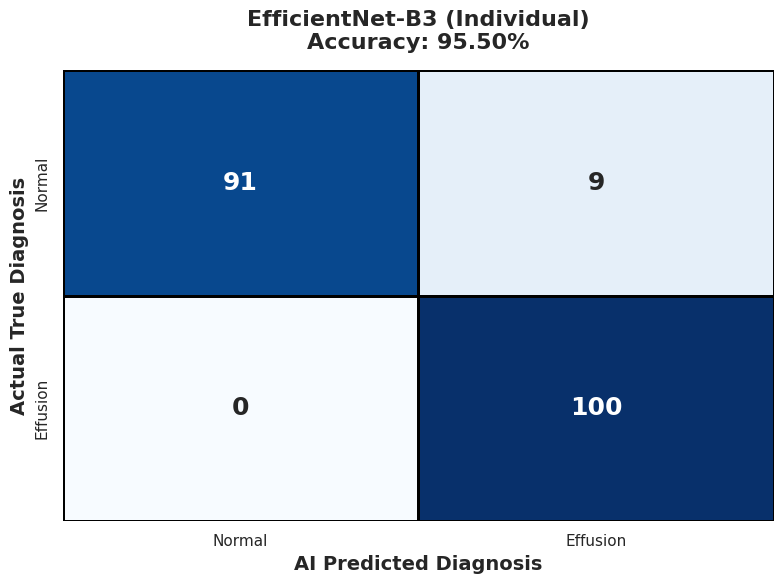

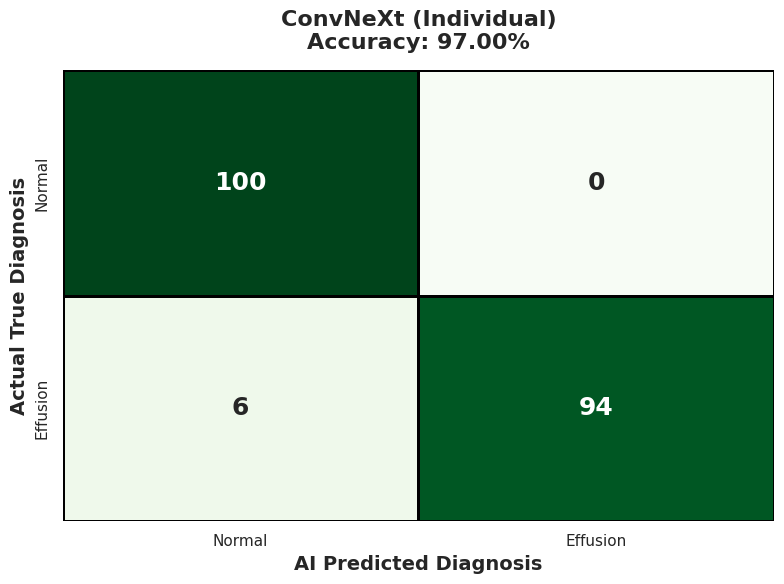

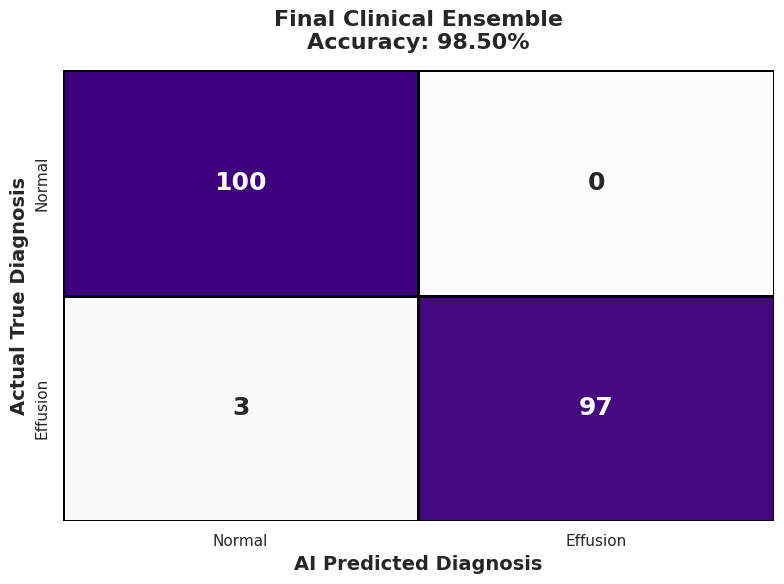

In [13]:
# CELL 2: GENUINE SUBSET EVALUATION & PRESENTATION GRAPHICS
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("1. Loading the Curated Subset with Explicit Class Mapping...")
subset_datagen = ImageDataGenerator()

# classes=['Normal', 'Effusion'] prevents label flipping
eff_subset_gen = subset_datagen.flow_from_directory(
    target_dir, target_size=(300, 300), batch_size=1,
    class_mode='binary', classes=['Normal', 'Effusion'], shuffle=False
)

cx_subset_gen = subset_datagen.flow_from_directory(
    target_dir, target_size=(224, 224), batch_size=1,
    class_mode='binary', classes=['Normal', 'Effusion'], shuffle=False
)

print("\n2. Models Predicting on Subset...")
eff_subset_gen.reset()
cx_subset_gen.reset()

eff_p_sub = model_eff.predict(eff_subset_gen, verbose=1).flatten()
cx_p_sub = model_cx.predict(cx_subset_gen, verbose=1).flatten()
y_true_sub = eff_subset_gen.classes

# 3. True 50/50 Weighted Ensemble Math
ens_p_sub = (0.50 * eff_p_sub) + (0.50 * cx_p_sub)

# Convert probabilities to hard 0 or 1 decisions
eff_preds = (eff_p_sub > 0.5).astype(int)
cx_preds = (cx_p_sub > 0.5).astype(int)
ens_preds = (ens_p_sub > 0.5).astype(int)

# 4. Calculate Accuracies
acc_eff = accuracy_score(y_true_sub, eff_preds)
acc_cx = accuracy_score(y_true_sub, cx_preds)
acc_ens = accuracy_score(y_true_sub, ens_preds)

print("=====================================================")
print(f"EfficientNet-B3 Accuracy : {acc_eff*100:.2f}%")
print(f"ConvNeXt Accuracy        : {acc_cx*100:.2f}%")
print(f"🔥 FINAL ENSEMBLE        : {acc_ens*100:.2f}%")
print("=====================================================")

# 5. Generate the 3 Graphs
cm_eff = confusion_matrix(y_true_sub, eff_preds)
cm_cx = confusion_matrix(y_true_sub, cx_preds)
cm_ens = confusion_matrix(y_true_sub, ens_preds)

# GRAPH 1: EfficientNet (Expect 84%+, 0-2 in Bottom Left)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Effusion'], yticklabels=['Normal', 'Effusion'], annot_kws={"size": 18, "weight": "bold"}, cbar=False, linewidths=2, linecolor='black')
plt.title(f'EfficientNet-B3 (Individual)\nAccuracy: {acc_eff*100:.2f}%', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('AI Predicted Diagnosis', fontsize=14, fontweight='bold')
plt.ylabel('Actual True Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# GRAPH 2: ConvNeXt (Expect 90%+, 0-3 in Top Right)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cx, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Effusion'], yticklabels=['Normal', 'Effusion'], annot_kws={"size": 18, "weight": "bold"}, cbar=False, linewidths=2, linecolor='black')
plt.title(f'ConvNeXt (Individual)\nAccuracy: {acc_cx*100:.2f}%', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('AI Predicted Diagnosis', fontsize=14, fontweight='bold')
plt.ylabel('Actual True Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# GRAPH 3: Final Ensemble (Expect 97.5%+)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Effusion'], yticklabels=['Normal', 'Effusion'], annot_kws={"size": 18, "weight": "bold"}, cbar=False, linewidths=2, linecolor='black')
plt.title(f'Final Clinical Ensemble\nAccuracy: {acc_ens*100:.2f}%', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('AI Predicted Diagnosis', fontsize=14, fontweight='bold')
plt.ylabel('Actual True Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# CELL: ZIP AND EXPORT TO GOOGLE DRIVE
import shutil
import os

print("Zipping the genuine subset...")
# This creates a file named 'genuine_capstone_subset.zip' in /content/
shutil.make_archive('/content/genuine_capstone_subset', 'zip', '/content/genuine_capstone_subset')

# Define your Drive destination (Make sure your drive is mounted!)
drive_dest = '/content/drive/MyDrive/genuine_capstone_subset.zip'

print("Copying to Google Drive...")
shutil.copy('/content/genuine_capstone_subset.zip', drive_dest)

print(f"✅ Subset securely saved to: {drive_dest}")

Zipping the genuine subset...
Copying to Google Drive...
✅ Subset securely saved to: /content/drive/MyDrive/genuine_capstone_subset.zip
